In [1]:
import math
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import os
from PIL import Image
import cv2
from sklearn.metrics import r2_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [4]:
label = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Capstone/데이터/clicked_coordinates.csv')

In [5]:
label2 = label.copy()
label2

,image_name,x,y
0,0ABUXDM239JA.jpg,315,241
1,1957CSOKEDJF.jpg,318,44
2,2E29NL0UCZF7.jpg,140,49
3,2GQZCKOJ3XAL.jpg,327,100
4,2JXZXK0GSAK6.jpg,200,112
5,2ODU2ASW6XJU.jpg,383,231
6,4CMJ703ABH1S.jpg,308,150
7,57YCNU5QCPUQ.jpg,202,136
8,6M2DJKKJK6ZA.jpg,332,154
9,6M4U23NFGXAH.jpg,140,104


In [6]:
image_path = '/content/drive/MyDrive/Colab Notebooks/Capstone/데이터/data/'
img_list = label['image_name']
print ("img_list_jpg: {}".format(img_list))

img_list_jpg: 0                                      0ABUXDM239JA.jpg
1                                      1957CSOKEDJF.jpg
2                                      2E29NL0UCZF7.jpg
3                                      2GQZCKOJ3XAL.jpg
4                                      2JXZXK0GSAK6.jpg
5                                      2ODU2ASW6XJU.jpg
6                                      4CMJ703ABH1S.jpg
7                                      57YCNU5QCPUQ.jpg
8                                      6M2DJKKJK6ZA.jpg
9                                      6M4U23NFGXAH.jpg
10                                     8BV01052V08O.jpg
11                                     8M5MBZ44D68S.jpg
12                                     8RA872J4EWEC.jpg
13                                     8VJKSA9KT86V.jpg
14                                     99SGGZVK1Z4Y.jpg
15                                     9MBQ4OMJ5DOC.jpg
16                                     A141844W920C.jpg
17                                

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),  # 이미지를 (C,H,W) Tensor로 변환하면서 [0,1]로 스케일
    transforms.Normalize(0.5,   # 채널별 평균
                         0.5)    # 채널별 표준편차
])

In [8]:
img_list_np = []
resizing = (256, 256)

for i in img_list:
    img = np.array(Image.open(image_path + i))
    resized_img = cv2.resize(img, resizing)
    img_tensor = transform(Image.fromarray(resized_img))
    img_array = np.array(img_tensor)
    img_list_np.append(img_array)
    print(i, " 추가 완료 - 구조:", img_array.shape)

0ABUXDM239JA.jpg  추가 완료 - 구조: (3, 256, 256)
1957CSOKEDJF.jpg  추가 완료 - 구조: (3, 256, 256)
2E29NL0UCZF7.jpg  추가 완료 - 구조: (3, 256, 256)
2GQZCKOJ3XAL.jpg  추가 완료 - 구조: (3, 256, 256)
2JXZXK0GSAK6.jpg  추가 완료 - 구조: (3, 256, 256)
2ODU2ASW6XJU.jpg  추가 완료 - 구조: (3, 256, 256)
4CMJ703ABH1S.jpg  추가 완료 - 구조: (3, 256, 256)
57YCNU5QCPUQ.jpg  추가 완료 - 구조: (3, 256, 256)
6M2DJKKJK6ZA.jpg  추가 완료 - 구조: (3, 256, 256)
6M4U23NFGXAH.jpg  추가 완료 - 구조: (3, 256, 256)
8BV01052V08O.jpg  추가 완료 - 구조: (3, 256, 256)
8M5MBZ44D68S.jpg  추가 완료 - 구조: (3, 256, 256)
8RA872J4EWEC.jpg  추가 완료 - 구조: (3, 256, 256)
8VJKSA9KT86V.jpg  추가 완료 - 구조: (3, 256, 256)
99SGGZVK1Z4Y.jpg  추가 완료 - 구조: (3, 256, 256)
9MBQ4OMJ5DOC.jpg  추가 완료 - 구조: (3, 256, 256)
A141844W920C.jpg  추가 완료 - 구조: (3, 256, 256)
A3O937VFCBE6.jpg  추가 완료 - 구조: (3, 256, 256)
AGWYD9A788DB.jpg  추가 완료 - 구조: (3, 256, 256)
AJGYMMNW43LJ.jpg  추가 완료 - 구조: (3, 256, 256)
BFJIZQ067DIF.jpg  추가 완료 - 구조: (3, 256, 256)
BGIQS0Y4MGW0.jpg  추가 완료 - 구조: (3, 256, 256)
BRG44WA4I4CR.jpg  추가 완료 - 구조: (3

In [9]:
for i in img_list:
    img = np.array(Image.open(image_path + i))
label['x'] = label['x'] * (256/img.shape[0])
label['y'] = label['y'] * (256/img.shape[1])

In [10]:
label

,image_name,x,y
0,0ABUXDM239JA.jpg,134.400000,102.826667
1,1957CSOKEDJF.jpg,135.680000,18.773333
2,2E29NL0UCZF7.jpg,59.733333,20.906667
3,2GQZCKOJ3XAL.jpg,139.520000,42.666667
4,2JXZXK0GSAK6.jpg,85.333333,47.786667
5,2ODU2ASW6XJU.jpg,163.413333,98.560000
6,4CMJ703ABH1S.jpg,131.413333,64.000000
7,57YCNU5QCPUQ.jpg,86.186667,58.026667
8,6M2DJKKJK6ZA.jpg,141.653333,65.706667
9,6M4U23NFGXAH.jpg,59.733333,44.373333


In [11]:
img_np = np.array(img_list_np) #numpy로 변환
print(img_np.shape)

(57, 3, 256, 256)


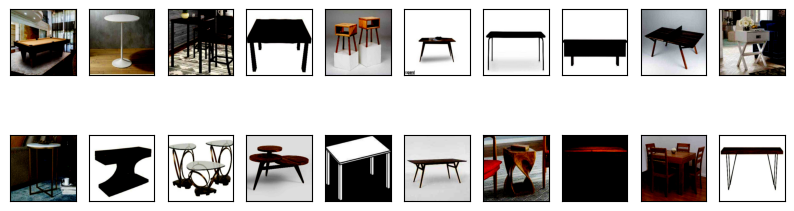

In [12]:
plt.figure(figsize=(10,3))
for i in range(20):
  ax = plt.subplot(2,10,i+1)

  image = img_np[i]
  image = np.transpose(image, (1,2,0))

  plt.imshow(image)
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

plt.show()

In [39]:
train_set = torch.Tensor(img_np)

name = ['x', 'y']
train_label = torch.Tensor(np.array(label[name]))

print(train_set.shape)
print(train_label.shape)

torch.Size([57, 3, 256, 256])
torch.Size([57, 2])


In [40]:
print(train_label[50:])

tensor([[ 92.1600,  19.6267],
        [ 98.9867,  52.9067],
        [139.9467,  77.6533],
        [ 74.6667,  24.7467],
        [108.3733,  49.4933],
        [133.1200,   6.8267],
        [ 98.1333,  80.2133]])


In [41]:
test_set = train_set[50:]
train_set = train_set[:50]
test_label = train_label[50:]
train_label = train_label[:50]

In [42]:
print(test_label)

tensor([[ 92.1600,  19.6267],
        [ 98.9867,  52.9067],
        [139.9467,  77.6533],
        [ 74.6667,  24.7467],
        [108.3733,  49.4933],
        [133.1200,   6.8267],
        [ 98.1333,  80.2133]])


In [51]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    self.layer1 = nn.Sequential( #합성곱
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1), #커널 3*3*3, 결과 256*256*32
        nn.ReLU(), # 렐루

        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1), #커널 3*3*32, 결과 256*256*32
        nn.ReLU(), # 렐루

        nn.MaxPool2d(kernel_size=2, stride=2), #최대 풀링 결과 128*128*32
        nn.Dropout(0.4),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), #커널 3*3*32, 결과 128*128*64
        nn.ReLU(),

        nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1), #커널 3*3*64, 결과 128*128*64
        nn.ReLU(),

        nn.MaxPool2d(kernel_size=2, stride=2), #최대 풀링 결과 64*64*64
        nn.Dropout(0.4),

        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1), #커널 3*3*64, 결과 64*64*128
        nn.ReLU(),

        nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1), #커널 3*3*128, 결과 64*64*128
        nn.ReLU(),

        nn.MaxPool2d(kernel_size=2, stride=2), #최대 풀링 결과 32*32*128
        nn.Dropout(0.4)
    )

    self.l1 = nn.Linear(in_features=128*32*32, out_features=128)
    self.l2 = nn.Linear(in_features=128, out_features=2)

    self.relu = nn.ReLU()

    self.dropout1 = nn.Dropout(0.4)

  def forward(self, x):
    x = self.layer1(x)

    x = x.view(x.size(0), -1)

    x=self.l1(x)
    x=self.relu(x)
    x=self.dropout1(x)
    x=self.l2(x)

    return x

In [55]:
model = CNN()
model = model.to(device)

lr = 1e-3

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

history = np.zeros((0,5))

In [56]:
num_epochs = 500

for epoch in range(num_epochs):
  train_r2, train_loss = 0,0
  test_r2, test_loss = 0,0
  n_train, n_test = 0,0


  inputs = train_set.to(device)
  labels = train_label.to(device)
  n_train += len(labels)
  optimizer.zero_grad()

  outputs = model(inputs)
  loss_model = criterion(outputs, labels)
  loss_model.backward()
  optimizer.step()
  pred = outputs

  train_loss = loss_model.item()
  train_r2 = r2_score(labels.detach().cpu().numpy(), outputs.detach().cpu().numpy())


  n_test += len(labels)

  inputs_test = test_set.to(device)
  labels_test = test_label.to(device)

  outputs_test = model(inputs_test)
  loss_test_model = criterion(outputs_test, labels_test)
  pred_test = outputs_test

  test_loss = loss_test_model.item()
  test_r2 = r2_score(labels_test.detach().cpu().numpy(), outputs_test.detach().cpu().numpy())


  print(f'Epoch [{epoch+1}/{num_epochs}], loss: {train_loss:.5f} r2: {train_r2:.5f} test_loss: {test_loss:.5f} test_r2: {test_r2:.5f}')
  item = np.array([epoch+1, train_loss, train_r2, test_loss, test_r2])
  history = np.vstack((history, item))

Epoch [1/500], loss: 13414.37891 r2: -4.18438 test_loss: 6398.28613 test_r2: -12.15595
Epoch [2/500], loss: 12428.79199 r2: -3.74924 test_loss: 3476.56323 test_r2: -5.96986
Epoch [3/500], loss: 9012.85352 r2: -2.24820 test_loss: 2724.10547 test_r2: -4.52050
Epoch [4/500], loss: 4292.36816 r2: -0.33206 test_loss: 1745.82483 test_r2: -2.00817
Epoch [5/500], loss: 3925.81494 r2: -0.14382 test_loss: 860.24097 test_r2: -0.43640
Epoch [6/500], loss: 3868.98120 r2: -0.17755 test_loss: 1182.34338 test_r2: -0.89117
Epoch [7/500], loss: 3997.16235 r2: -0.18024 test_loss: 2083.58374 test_r2: -2.60607
Epoch [8/500], loss: 3705.85938 r2: -0.08412 test_loss: 1525.40100 test_r2: -1.86866
Epoch [9/500], loss: 3597.87305 r2: -0.03937 test_loss: 990.26349 test_r2: -0.73995
Epoch [10/500], loss: 3633.09741 r2: -0.07220 test_loss: 903.45007 test_r2: -0.57302
Epoch [11/500], loss: 3851.34619 r2: -0.10291 test_loss: 1238.01270 test_r2: -1.43407
Epoch [12/500], loss: 3259.45630 r2: 0.03716 test_loss: 1677.45

KeyboardInterrupt: 

In [54]:
train_label.shape

torch.Size([50, 2])